# Revenue at Risk Analysis

This notebook estimates the potential customer value at risk from churn. Since the dataset does not contain transaction-level history, purchase frequency, or discount rates required for a full customer lifetime value model, a simplified CLV-at-risk framework is used.

Customer value is estimated using available financial and behavioural proxies such as account balance, estimated salary, tenure, and reward points. This value is then multiplied by each customer's churn probability to estimate expected revenue at risk.

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/churn_predictions.csv")
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned,AgeGroup,BalanceGroup,TenureGroup,SalaryGroup,Cluster,ChurnProbability,PredictedChurn,RiskCategory
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,41-50,No Balance,New,High,0,0.307647,0,Medium Risk
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,41-50,Medium,New,High,0,0.210793,0,Low Risk
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,41-50,Very High,Long,High,3,0.970657,1,High Risk
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,31-40,No Balance,New,Medium,3,0.057732,0,Low Risk
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,41-50,High,New,Medium,0,0.083157,0,Low Risk


In [66]:
# check required columns
required_columns = [
    "Balance",
    "EstimatedSalary",
    "Tenure",
    "PointEarned",
    "ChurnProbability",
    "RiskCategory",
    "Cluster",
    "Geography"
]

df[required_columns].head()

,Balance,EstimatedSalary,Tenure,PointEarned,ChurnProbability,RiskCategory,Cluster,Geography
0,0.00,101348.88,2,464,0.307647,Medium Risk,0,France
1,83807.86,112542.58,1,456,0.210793,Low Risk,0,Spain
2,159660.80,113931.57,8,377,0.970657,High Risk,3,France
3,0.00,93826.63,1,350,0.057732,Low Risk,3,France
4,125510.82,79084.10,2,425,0.083157,Low Risk,0,Spain


## Customer Value Framework

A full CLV model cannot be built from this dataset because transaction-level customer history is not available.

Instead, a simplified customer value score is created using:

- Account balance: 40%
- Estimated salary: 30%
- Customer tenure: 20%
- Reward points earned: 10%

These weights are used to approximate relative customer value within the bank. Account balance receives the highest weight because it is the most direct financial indicator available in the dataset.

In [67]:
# create normalised value scores
df["BalanceScore"] = df["Balance"] / df["Balance"].max()
df["SalaryScore"] = df["EstimatedSalary"] / df["EstimatedSalary"].max()
df["TenureScore"] = df["Tenure"] / df["Tenure"].max()
df["PointsScore"] = df["PointEarned"] / df["PointEarned"].max()

df[[
    "BalanceScore",
    "SalaryScore",
    "TenureScore",
    "PointsScore"
]].head()

,BalanceScore,SalaryScore,TenureScore,PointsScore
0,0.000000,0.506763,0.2,0.464
1,0.334031,0.562734,0.1,0.456
2,0.636357,0.569679,0.8,0.377
3,0.000000,0.469151,0.1,0.350
4,0.500246,0.395435,0.2,0.425


In [68]:
# create customer value score
df["CustomerValueScore"] = (
    0.40 * df["BalanceScore"] +
    0.30 * df["SalaryScore"] +
    0.20 * df["TenureScore"] +
    0.10 * df["PointsScore"]
)

df[["CustomerValueScore"]].head()

,CustomerValueScore
0,0.238429
1,0.368033
2,0.623147
3,0.195745
4,0.401229


In [69]:
# estimate customer value
df["EstimatedCustomerValue"] = df["CustomerValueScore"] * df["EstimatedSalary"]

df[[
    "Balance",
    "EstimatedSalary",
    "CustomerValueScore",
    "EstimatedCustomerValue"
]].head()

,Balance,EstimatedSalary,CustomerValueScore,EstimatedCustomerValue
0,0.00,101348.88,0.238429,24164.515788
1,83807.86,112542.58,0.368033,41419.361862
2,159660.80,113931.57,0.623147,70996.076329
3,0.00,93826.63,0.195745,18366.115928
4,125510.82,79084.10,0.401229,31730.842007


In [70]:
# calculate revenue at risk
df["RevenueAtRisk"] = df["EstimatedCustomerValue"] * df["ChurnProbability"]

df[[
    "EstimatedCustomerValue",
    "ChurnProbability",
    "RevenueAtRisk"
]].head()

,EstimatedCustomerValue,ChurnProbability,RevenueAtRisk
0,24164.515788,0.307647,7434.152146
1,41419.361862,0.210793,8730.897048
2,70996.076329,0.970657,68912.845561
3,18366.115928,0.057732,1060.309060
4,31730.842007,0.083157,2638.633061


In [71]:
# overall business impact
total_revenue_at_risk = df["RevenueAtRisk"].sum()
average_revenue_at_risk = df["RevenueAtRisk"].mean()
median_revenue_at_risk = df["RevenueAtRisk"].median()

print(f"Total Revenue at Risk: ${total_revenue_at_risk:,.2f}")
print(f"Average Revenue at Risk per Customer: ${average_revenue_at_risk:,.2f}")
print(f"Median Revenue at Risk per Customer: ${median_revenue_at_risk:,.2f}")

Total Revenue at Risk: $105,945,787.86
Average Revenue at Risk per Customer: $10,594.58
Median Revenue at Risk per Customer: $3,741.65


## Revenue at Risk by Risk Tier

This section summarises how revenue at risk is distributed across customer risk categories. This is useful for dashboard KPI cards and business-level reporting.

In [72]:
tier_summary = (
    df.groupby("RiskCategory")
    .agg(
        CustomerCount=("RevenueAtRisk", "count"),
        TotalRevenueAtRisk=("RevenueAtRisk", "sum"),
        AvgRevenueAtRisk=("RevenueAtRisk", "mean")
    )
    .reset_index()
)

tier_summary["RevenueAtRiskShare"] = (
    tier_summary["TotalRevenueAtRisk"] / tier_summary["TotalRevenueAtRisk"].sum()
) * 100

tier_summary = tier_summary.sort_values(
    by="TotalRevenueAtRisk",
    ascending=False
)

print(tier_summary)

high_risk_share = tier_summary.loc[
    tier_summary["RiskCategory"] == "High Risk",
    "RevenueAtRiskShare"
].iloc[0]

print(f"{high_risk_share:.2f}% of total revenue at risk sits in the High Risk tier.")

  RiskCategory  CustomerCount  TotalRevenueAtRisk  AvgRevenueAtRisk  \
1     Low Risk           7801        3.717155e+07       4764.972442   
0    High Risk            755        3.531784e+07      46778.599366   
2  Medium Risk           1444        3.345640e+07      23169.248833   

   RevenueAtRiskShare  
1           35.085444  
0           33.335768  
2           31.578788  
33.34% of total revenue at risk sits in the High Risk tier.


### Insight

This summary table provides a dashboard-ready view of revenue exposure by risk tier. It shows not only the total revenue at risk in each category, but also the percentage share of total exposure.

This is useful for executive reporting because it allows the dashboard to display a clear headline KPI such as the share of total revenue at risk sitting in the High Risk tier.

In [73]:
# helper functions: 
# for labels
def add_currency_labels(ax):
    for p in ax.patches:
        ax.annotate(
            f"${p.get_height():,.0f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

# for side-by-side total vs average revenue at risk charts
def plot_total_vs_average(data, group_col, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(
        data=data,
        x=group_col,
        y="TotalRevenueAtRisk",
        hue=group_col,
        palette="rocket",
        legend=False,
        ax=axes[0]
    )

    axes[0].set_title(f"Total Revenue at Risk by {title}")
    axes[0].set_xlabel(title)
    axes[0].set_ylabel("Total Revenue at Risk")

    for p in axes[0].patches:
        axes[0].annotate(
            f"${p.get_height():,.0f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    sns.barplot(
        data=data,
        x=group_col,
        y="AvgRevenueAtRisk",
        hue=group_col,
        palette="mako",
        legend=False,
        ax=axes[1]
    )

    axes[1].set_title(f"Average Revenue at Risk by {title}")
    axes[1].set_xlabel(title)
    axes[1].set_ylabel("Average Revenue at Risk per Customer")

    for p in axes[1].patches:
        axes[1].annotate(
            f"${p.get_height():,.0f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

  RiskCategory  CustomerCount  TotalRevenueAtRisk  AvgRevenueAtRisk  \
1     Low Risk           7801        3.717155e+07       4764.972442   
0    High Risk            755        3.531784e+07      46778.599366   
2  Medium Risk           1444        3.345640e+07      23169.248833   

   AvgChurnProbability  AvgCustomerValue  
1             0.094413      47467.554533  
0             0.864812      54159.162247  
2             0.457081      50397.592704  


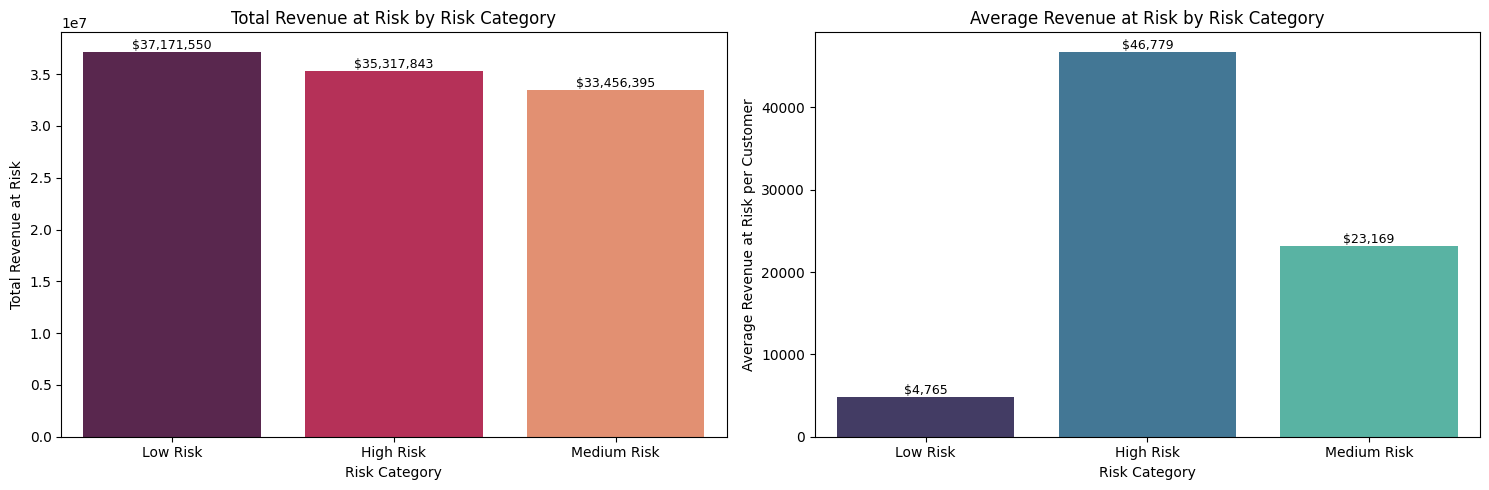

In [74]:
# revenue at risk by risk category
risk_revenue = (
    df.groupby("RiskCategory")
    .agg(
        CustomerCount=("RevenueAtRisk", "count"),
        TotalRevenueAtRisk=("RevenueAtRisk", "sum"),
        AvgRevenueAtRisk=("RevenueAtRisk", "mean"),
        AvgChurnProbability=("ChurnProbability", "mean"),
        AvgCustomerValue=("EstimatedCustomerValue", "mean")
    )
    .reset_index()
    .sort_values(by="TotalRevenueAtRisk", ascending=False)
)

print(risk_revenue)

plot_total_vs_average(risk_revenue, "RiskCategory", "Risk Category")

### Insight

The total revenue at risk is fairly close across the three risk categories, with Low Risk customers contributing the highest total exposure at approximately $37.2M. This is because Low Risk customers likely represent a much larger portion of the customer base.

However, the average revenue at risk per customer tells a different story. High Risk customers have the highest average exposure at approximately $46.8K per customer, compared with $23.2K for Medium Risk and only $4.8K for Low Risk. This means High Risk customers should be prioritised for individual retention actions, while Low Risk customers still matter at a portfolio level due to their scale.

  Geography  CustomerCount  TotalRevenueAtRisk  AvgRevenueAtRisk  \
1   Germany           2509        4.639368e+07      18490.903357   
0    France           5014        3.895981e+07       7770.205693   
2     Spain           2477        2.059230e+07       8313.403305   

   AvgChurnProbability  AvgCustomerValue  
1             0.326548      56171.341948  
0             0.161783      45875.015248  
2             0.169149      45622.713312  


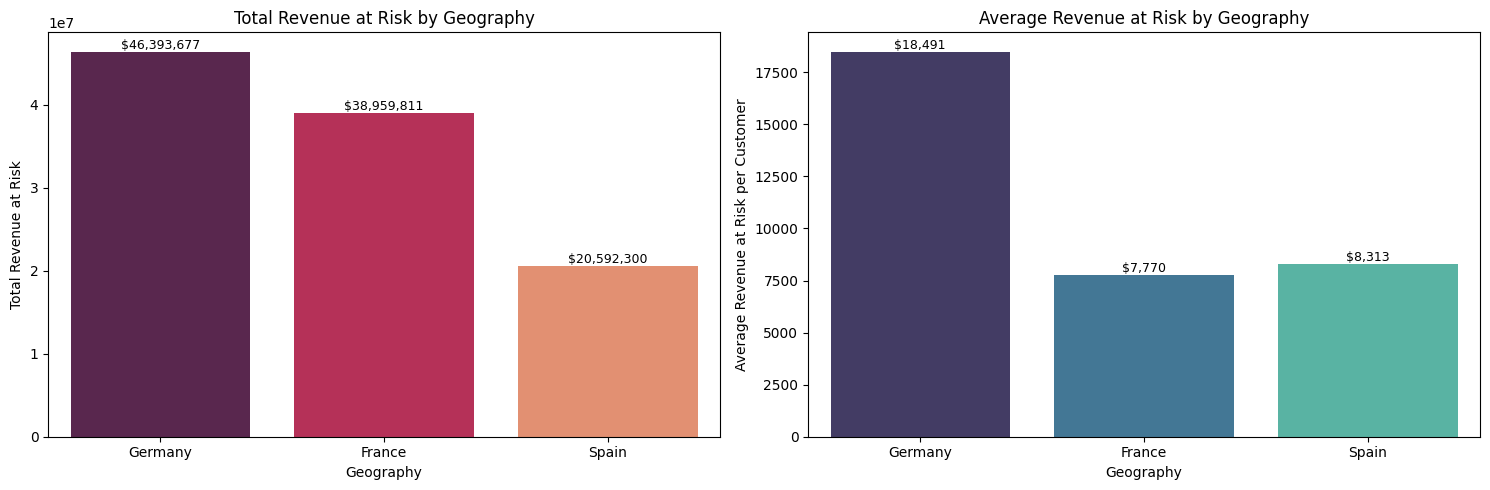

In [75]:
# revenue at risk by geography
geo_revenue = (
    df.groupby("Geography")
    .agg(
        CustomerCount=("RevenueAtRisk", "count"),
        TotalRevenueAtRisk=("RevenueAtRisk", "sum"),
        AvgRevenueAtRisk=("RevenueAtRisk", "mean"),
        AvgChurnProbability=("ChurnProbability", "mean"),
        AvgCustomerValue=("EstimatedCustomerValue", "mean")
    )
    .reset_index()
    .sort_values(by="TotalRevenueAtRisk", ascending=False)
)

print(geo_revenue)

plot_total_vs_average(geo_revenue, "Geography", "Geography")

### Insight

Germany has the highest total revenue at risk at approximately $46.4M, followed by France at $39.0M and Spain at $20.6M. Germany also has the highest average revenue at risk per customer at approximately $18.5K.

This suggests Germany is the most financially exposed market in the dataset, both in total terms and on a per-customer basis. Retention efforts in Germany may therefore have a stronger business impact than focusing equally across all regions.

   Cluster  CustomerCount  TotalRevenueAtRisk  AvgRevenueAtRisk  \
2        2           3249        4.977137e+07      15318.980606   
0        0           2875        2.138382e+07       7437.849619   
1        1           1116        1.869442e+07      16751.270186   
3        3           2760        1.609618e+07       5831.950972   

   AvgChurnProbability  AvgCustomerValue  
2             0.280406      54207.028654  
0             0.140502      53236.599397  
1             0.358433      45386.436489  
3             0.121188      37729.551373  


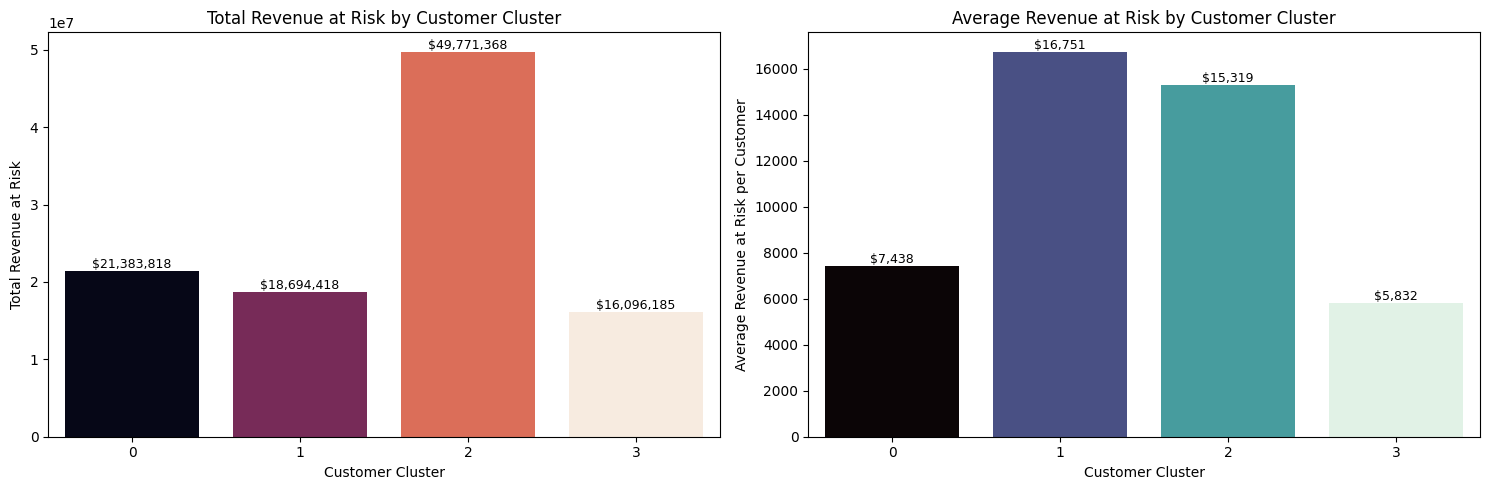

In [76]:
# revenue at risk by cluster
cluster_revenue = (
    df.groupby("Cluster")
    .agg(
        CustomerCount=("RevenueAtRisk", "count"),
        TotalRevenueAtRisk=("RevenueAtRisk", "sum"),
        AvgRevenueAtRisk=("RevenueAtRisk", "mean"),
        AvgChurnProbability=("ChurnProbability", "mean"),
        AvgCustomerValue=("EstimatedCustomerValue", "mean")
    )
    .reset_index()
    .sort_values(by="TotalRevenueAtRisk", ascending=False)
)

print(cluster_revenue)

plot_total_vs_average(cluster_revenue, "Cluster", "Customer Cluster")

### Insight

Cluster 2 contributes the highest total revenue at risk at approximately $49.8M, making it the largest source of overall financial exposure. However, Cluster 1 has the highest average revenue at risk per customer at approximately $16.8K, followed closely by Cluster 2 at $15.3K.

This means Cluster 2 is the most important segment from a total business exposure perspective, while Cluster 1 contains customers who are individually more valuable or risky. A strong retention strategy should prioritise Cluster 2 for broad segment-level campaigns and Cluster 1 for more targeted high-value customer outreach.

In [77]:
# top high-value at-risk customers
top_at_risk_customers = (
    df.sort_values(by="RevenueAtRisk", ascending=False)
    [[
        "Geography",
        "Gender",
        "Age",
        "Balance",
        "EstimatedSalary",
        "ChurnProbability",
        "RiskCategory",
        "Cluster",
        "EstimatedCustomerValue",
        "RevenueAtRisk"
    ]]
    .head(20)
)

top_at_risk_customers.style.format({
    "Balance": "${:,.0f}",
    "EstimatedSalary": "${:,.0f}",
    "ChurnProbability": "{:.1%}",
    "EstimatedCustomerValue": "${:,.0f}",
    "RevenueAtRisk": "${:,.0f}"
})

,Geography,Gender,Age,Balance,EstimatedSalary,ChurnProbability,RiskCategory,Cluster,EstimatedCustomerValue,RevenueAtRisk
2977,Spain,Female,45,"$131,355","$195,395",96.7%,High Risk,3,"$146,277","$141,522"
7590,Germany,Female,42,"$132,796","$191,821",95.7%,High Risk,3,"$142,707","$136,608"
5114,France,Male,60,"$185,649","$192,157",87.5%,High Risk,2,"$152,768","$133,659"
4967,Germany,Male,40,"$174,127","$172,491",95.5%,High Risk,2,"$137,260","$131,103"
413,Germany,Female,41,"$181,461","$187,929",87.0%,High Risk,0,"$149,254","$129,840"
617,Germany,Female,62,"$140,745","$193,438",91.2%,High Risk,1,"$139,286","$127,092"
5297,Germany,Male,51,"$97,750","$193,014",96.8%,High Risk,3,"$131,129","$126,923"
8393,Germany,Male,60,"$148,846","$192,832",89.2%,High Risk,1,"$142,225","$126,797"
2124,France,Male,32,"$127,785","$184,465",95.5%,High Risk,3,"$132,544","$126,547"
2053,France,Male,63,"$169,833","$184,107",84.7%,High Risk,1,"$147,917","$125,280"


### Insight

The customers shown above represent the highest-value accounts that are also predicted to have elevated churn risk.

These customers should be prioritised for proactive retention campaigns because losing even a small number of them could have a disproportionate financial impact on the bank.

In [78]:
# save output
df.to_csv("../data/revenue_at_risk.csv", index=False)

## Summary

This notebook implemented a simplified CLV-at-risk framework using the available customer-level data.

Because the dataset does not include transaction history, purchase frequency, retention history, or discount rates, customer value was estimated using financial and behavioural proxies: balance, estimated salary, tenure, and reward points.

Revenue at risk was calculated by multiplying estimated customer value by predicted churn probability. This allows the business to prioritise customers who are not only likely to churn, but also financially valuable.

Two views of revenue at risk were considered:

- Total revenue at risk: useful for understanding business-wide exposure.
- Average revenue at risk per customer: useful for prioritising individual or segment-level retention actions.

The final output was saved as `revenue_at_risk.csv` and will be used in the Streamlit dashboard and retention recommendation engine.
The combination of churn prediction, customer segmentation, and revenue-at-risk analysis provides a more business-focused view of customer retention than prediction alone.